# Bias, Harms, and Fairness Metrics

Objective: Use the real Adult Census Income dataset to connect fairness metrics to possible harms without making claims that the evidence cannot support.

Based on:
- Adult Census Income dataset from UCI, accessed through HuggingFace
- Hardt, Price, and Srebro (2016), "Equality of Opportunity in Supervised Learning"

## What you will do

1. Load and inspect a real tabular dataset used in fairness demos.
2. Train two simple models with different protected-attribute feature policies.
3. Compute selection rate, TPR, FPR, FNR, and accuracy by group.
4. Compare group gaps with and without protected attributes.
5. Explain why a metric gap is evidence to investigate, not a final fairness judgment.

## Background

The Adult Census Income task predicts whether income is greater than 50K. This is a common teaching dataset in fairness research. We use it to practice careful metric reasoning, not to make a deployment recommendation.

The key question is simple: if we remove `sex` and `race` from the model inputs, do group gaps disappear? The answer is usually more complicated than yes or no because other features may still act as proxies.


In [1]:
# Setup: import libraries for this fairness demo

import os  # controls a few dataset download settings
import numpy as np  # stores numbers and handles missing metric values
import pandas as pd  # stores data tables
import matplotlib.pyplot as plt  # makes simple charts
from datasets import load_dataset  # downloads datasets from HuggingFace
from sklearn.linear_model import LogisticRegression  # trains a simple classification model
from sklearn.metrics import accuracy_score  # measures the share of correct predictions
from sklearn.model_selection import train_test_split  # splits data into training and test rows

os.environ["HF_HUB_DISABLE_PROGRESS_BARS"] = "1"


## Step 1: Load the Dataset

We start by downloading the Adult Census Income dataset from HuggingFace. The original dataset comes from the UCI Machine Learning Repository.


In [2]:
# Download and inspect the Adult Census Income dataset

adult_dataset = load_dataset("scikit-learn/adult-census-income")
adult_raw = adult_dataset["train"].to_pandas()

print("Dataset source: scikit-learn/adult-census-income on HuggingFace")
print("Rows:", len(adult_raw))
print("Columns:", len(adult_raw.columns))

adult_raw.head()


Dataset source: scikit-learn/adult-census-income on HuggingFace
Rows: 32561
Columns: 15


,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,?,77053,HS-grad,9,Widowed,?,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,?,186061,Some-college,10,Widowed,?,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K


## Step 2: Prepare the Dataset

The dataset has missing values written as `?`. We remove those rows for this beginner demo so the first fairness calculation is easier to follow.


In [3]:
# Clean column names and create the prediction target

adult_data = adult_raw.copy()
adult_data.columns = adult_data.columns.str.replace(".", "_", regex=False)

for column_name in adult_data.columns:
    if adult_data[column_name].dtype == "object":
        adult_data[column_name] = adult_data[column_name].astype(str).str.strip()

adult_data = adult_data.replace("?", np.nan)
adult_data = adult_data.dropna().reset_index(drop=True)

adult_data["income_over_50k"] = 0
adult_data.loc[adult_data["income"].str.contains(">50K", regex=False), "income_over_50k"] = 1

print("Rows after dropping rows with unknown values:", len(adult_data))
print("Positive label means income is greater than 50K.")

adult_data["income_over_50k"].value_counts(normalize=True).rename("share")


Rows after dropping rows with unknown values: 30162
Positive label means income is greater than 50K.


income_over_50k
0    0.751078
1    0.248922
Name: share, dtype: float64

## Step 3: Train Two Models

We compare two models. The first can use `sex` and `race`. The second excludes those columns from the model features. We still keep `sex` and `race` in the test data for auditing.


In [4]:
# Train two logistic regression models for comparison

train_data, test_data = train_test_split(
    adult_data,
    test_size=0.25,
    random_state=42,
    stratify=adult_data["income_over_50k"],
)

protected_columns = ["sex", "race"]
with_protected_feature_columns = []
without_protected_feature_columns = []

for column_name in adult_data.columns:
    if column_name != "income" and column_name != "income_over_50k":
        with_protected_feature_columns.append(column_name)
        if column_name != "sex" and column_name != "race":
            without_protected_feature_columns.append(column_name)

with_protected_train_features = train_data[with_protected_feature_columns].copy()
with_protected_test_features = test_data[with_protected_feature_columns].copy()
without_protected_train_features = train_data[without_protected_feature_columns].copy()
without_protected_test_features = test_data[without_protected_feature_columns].copy()

for column_name in with_protected_feature_columns:
    if pd.api.types.is_numeric_dtype(with_protected_train_features[column_name]):
        training_mean = with_protected_train_features[column_name].mean()
        training_std = with_protected_train_features[column_name].std()
        if training_std == 0:
            training_std = 1
        with_protected_train_features[column_name] = (with_protected_train_features[column_name] - training_mean) / training_std
        with_protected_test_features[column_name] = (with_protected_test_features[column_name] - training_mean) / training_std

for column_name in without_protected_feature_columns:
    if pd.api.types.is_numeric_dtype(without_protected_train_features[column_name]):
        training_mean = without_protected_train_features[column_name].mean()
        training_std = without_protected_train_features[column_name].std()
        if training_std == 0:
            training_std = 1
        without_protected_train_features[column_name] = (without_protected_train_features[column_name] - training_mean) / training_std
        without_protected_test_features[column_name] = (without_protected_test_features[column_name] - training_mean) / training_std

with_protected_train_encoded = pd.get_dummies(with_protected_train_features)
with_protected_test_encoded = pd.get_dummies(with_protected_test_features)
with_protected_test_encoded = with_protected_test_encoded.reindex(columns=with_protected_train_encoded.columns, fill_value=0)

without_protected_train_encoded = pd.get_dummies(without_protected_train_features)
without_protected_test_encoded = pd.get_dummies(without_protected_test_features)
without_protected_test_encoded = without_protected_test_encoded.reindex(columns=without_protected_train_encoded.columns, fill_value=0)

training_labels = train_data["income_over_50k"]
test_labels = test_data["income_over_50k"]

with_protected_model = LogisticRegression(max_iter=1000, class_weight="balanced")
with_protected_model.fit(with_protected_train_encoded, training_labels)
with_protected_predictions = with_protected_model.predict(with_protected_test_encoded)
with_protected_scores = with_protected_model.predict_proba(with_protected_test_encoded)[:, 1]

without_protected_model = LogisticRegression(max_iter=1000, class_weight="balanced")
without_protected_model.fit(without_protected_train_encoded, training_labels)
without_protected_predictions = without_protected_model.predict(without_protected_test_encoded)
without_protected_scores = without_protected_model.predict_proba(without_protected_test_encoded)[:, 1]

model_accuracy_table = pd.DataFrame({
    "model": ["with_protected", "without_protected"],
    "overall_accuracy": [
        accuracy_score(test_labels, with_protected_predictions),
        accuracy_score(test_labels, without_protected_predictions),
    ],
})

model_accuracy_table.round(3)


,model,overall_accuracy
0,with_protected,0.818
1,without_protected,0.817


## Step 4: Compare Fairness Metrics by Group

Overall accuracy is not enough. We compute selection rate, TPR, FPR, FNR, and accuracy by `sex` and by `race`.


In [5]:
# Compute group metrics for sex and race

audit_results = test_data[["sex", "race", "income_over_50k"]].copy()
audit_results["with_protected_prediction"] = with_protected_predictions
audit_results["without_protected_prediction"] = without_protected_predictions
audit_results["without_protected_score"] = without_protected_scores

metric_rows = []
model_prediction_columns = {
    "with_protected": "with_protected_prediction",
    "without_protected": "without_protected_prediction",
}

for model_name, prediction_column in model_prediction_columns.items():
    for group_column in ["sex", "race"]:
        for group_name, group_rows in audit_results.groupby(group_column):
            true_positive_count = 0
            false_positive_count = 0
            true_negative_count = 0
            false_negative_count = 0

            for row_number, prediction_row in group_rows.iterrows():
                true_label = prediction_row["income_over_50k"]
                predicted_label = prediction_row[prediction_column]

                if true_label == 1 and predicted_label == 1:
                    true_positive_count = true_positive_count + 1
                if true_label == 0 and predicted_label == 1:
                    false_positive_count = false_positive_count + 1
                if true_label == 0 and predicted_label == 0:
                    true_negative_count = true_negative_count + 1
                if true_label == 1 and predicted_label == 0:
                    false_negative_count = false_negative_count + 1

            group_size = len(group_rows)
            actual_positive_count = true_positive_count + false_negative_count
            actual_negative_count = false_positive_count + true_negative_count
            selection_rate = (true_positive_count + false_positive_count) / group_size
            accuracy = (true_positive_count + true_negative_count) / group_size

            if actual_positive_count == 0:
                true_positive_rate = np.nan
                false_negative_rate = np.nan
            else:
                true_positive_rate = true_positive_count / actual_positive_count
                false_negative_rate = false_negative_count / actual_positive_count

            if actual_negative_count == 0:
                false_positive_rate = np.nan
            else:
                false_positive_rate = false_positive_count / actual_negative_count

            metric_rows.append({
                "model": model_name,
                "group_column": group_column,
                "group": group_name,
                "n": group_size,
                "TP": true_positive_count,
                "FP": false_positive_count,
                "TN": true_negative_count,
                "FN": false_negative_count,
                "actual_positive_count": actual_positive_count,
                "selection_rate": selection_rate,
                "TPR": true_positive_rate,
                "FPR": false_positive_rate,
                "FNR": false_negative_rate,
                "accuracy": accuracy,
            })

group_metrics = pd.DataFrame(metric_rows)
group_metrics.round(3)


,model,group_column,group,n,TP,FP,TN,FN,actual_positive_count,selection_rate,TPR,FPR,FNR,accuracy
0,with_protected,sex,Female,2422,192,151,1994,85,277,0.142,0.693,0.070,0.307,0.903
1,with_protected,sex,Male,5119,1400,934,2585,200,1600,0.456,0.875,0.265,0.125,0.778
2,with_protected,race,Amer-Indian-Eskimo,56,6,1,46,3,9,0.125,0.667,0.021,0.333,0.929
3,with_protected,race,Asian-Pac-Islander,221,51,37,127,6,57,0.398,0.895,0.226,0.105,0.805
4,with_protected,race,Black,700,75,52,544,29,104,0.181,0.721,0.087,0.279,0.884
5,with_protected,race,Other,66,4,1,59,2,6,0.076,0.667,0.017,0.333,0.955
6,with_protected,race,White,6498,1456,994,3803,245,1701,0.377,0.856,0.207,0.144,0.809
7,without_protected,sex,Female,2422,202,179,1966,75,277,0.157,0.729,0.083,0.271,0.895
8,without_protected,sex,Male,5119,1379,906,2613,221,1600,0.446,0.862,0.257,0.138,0.780
9,without_protected,race,Amer-Indian-Eskimo,56,6,6,41,3,9,0.214,0.667,0.128,0.333,0.839


## Step 5: Turn Group Metrics into Gaps

A gap is the largest group value minus the smallest group value. A gap is evidence to investigate, not a complete fairness judgment.


In [6]:
# Compute max-minus-min gaps for each metric

gap_rows = []

for model_name in ["with_protected", "without_protected"]:
    for group_column in ["sex", "race"]:
        selected_metrics = group_metrics[
            (group_metrics["model"] == model_name)
            & (group_metrics["group_column"] == group_column)
        ]

        gap_rows.append({
            "model": model_name,
            "group_column": group_column,
            "selection_rate_gap": selected_metrics["selection_rate"].max() - selected_metrics["selection_rate"].min(),
            "TPR_gap": selected_metrics["TPR"].max() - selected_metrics["TPR"].min(),
            "FPR_gap": selected_metrics["FPR"].max() - selected_metrics["FPR"].min(),
            "FNR_gap": selected_metrics["FNR"].max() - selected_metrics["FNR"].min(),
            "accuracy_gap": selected_metrics["accuracy"].max() - selected_metrics["accuracy"].min(),
        })

gap_table = pd.DataFrame(gap_rows)
gap_table.round(3)


,model,group_column,selection_rate_gap,TPR_gap,FPR_gap,FNR_gap,accuracy_gap
0,with_protected,sex,0.314,0.182,0.195,0.182,0.124
1,with_protected,race,0.322,0.228,0.209,0.228,0.149
2,without_protected,sex,0.289,0.133,0.174,0.133,0.115
3,without_protected,race,0.270,0.193,0.157,0.193,0.115


## Step 6: Test Threshold Sensitivity

The default threshold is 0.50. Changing the threshold can change both accuracy and group gaps. Because the `<=50K` class is the majority class in this dataset, a higher threshold can sometimes increase overall accuracy while also changing TPR, FPR, and FNR. This is why accuracy alone is not enough for a fairness audit.


In [7]:
# Sweep thresholds for the model that excludes protected attributes

threshold_rows = []

for threshold in [0.30, 0.40, 0.50, 0.60, 0.70]:
    audit_results["threshold_prediction"] = (audit_results["without_protected_score"] >= threshold).astype(int)
    overall_accuracy = accuracy_score(audit_results["income_over_50k"], audit_results["threshold_prediction"])

    for group_column in ["sex", "race"]:
        threshold_metric_rows = []

        for group_name, group_rows in audit_results.groupby(group_column):
            true_positive_count = 0
            false_positive_count = 0
            true_negative_count = 0
            false_negative_count = 0

            for row_number, prediction_row in group_rows.iterrows():
                true_label = prediction_row["income_over_50k"]
                predicted_label = prediction_row["threshold_prediction"]

                if true_label == 1 and predicted_label == 1:
                    true_positive_count = true_positive_count + 1
                if true_label == 0 and predicted_label == 1:
                    false_positive_count = false_positive_count + 1
                if true_label == 0 and predicted_label == 0:
                    true_negative_count = true_negative_count + 1
                if true_label == 1 and predicted_label == 0:
                    false_negative_count = false_negative_count + 1

            group_size = len(group_rows)
            actual_positive_count = true_positive_count + false_negative_count
            actual_negative_count = false_positive_count + true_negative_count
            selection_rate = (true_positive_count + false_positive_count) / group_size

            if actual_positive_count == 0:
                true_positive_rate = np.nan
                false_negative_rate = np.nan
            else:
                true_positive_rate = true_positive_count / actual_positive_count
                false_negative_rate = false_negative_count / actual_positive_count

            if actual_negative_count == 0:
                false_positive_rate = np.nan
            else:
                false_positive_rate = false_positive_count / actual_negative_count

            threshold_metric_rows.append({
                "selection_rate": selection_rate,
                "TPR": true_positive_rate,
                "FPR": false_positive_rate,
                "FNR": false_negative_rate,
            })

        threshold_metric_table = pd.DataFrame(threshold_metric_rows)
        threshold_rows.append({
            "threshold": threshold,
            "group_column": group_column,
            "overall_accuracy": overall_accuracy,
            "selection_rate_gap": threshold_metric_table["selection_rate"].max() - threshold_metric_table["selection_rate"].min(),
            "TPR_gap": threshold_metric_table["TPR"].max() - threshold_metric_table["TPR"].min(),
            "FPR_gap": threshold_metric_table["FPR"].max() - threshold_metric_table["FPR"].min(),
            "FNR_gap": threshold_metric_table["FNR"].max() - threshold_metric_table["FNR"].min(),
        })

threshold_sweep = pd.DataFrame(threshold_rows)
threshold_sweep.round(3)


,threshold,group_column,overall_accuracy,selection_rate_gap,TPR_gap,FPR_gap,FNR_gap
0,0.3,sex,0.741,0.351,0.084,0.268,0.084
1,0.3,race,0.741,0.229,0.114,0.174,0.114
2,0.4,sex,0.783,0.328,0.131,0.224,0.131
3,0.4,race,0.783,0.272,0.242,0.155,0.242
4,0.5,sex,0.817,0.289,0.133,0.174,0.133
5,0.5,race,0.817,0.270,0.193,0.157,0.193
6,0.6,sex,0.839,0.235,0.115,0.117,0.115
7,0.6,race,0.839,0.236,0.126,0.130,0.126
8,0.7,sex,0.851,0.189,0.103,0.074,0.103
9,0.7,race,0.851,0.197,0.168,0.105,0.168


## Step 7: Visualize the Threshold Trade-Off

The chart below focuses on the model that excludes protected attributes. This helps test the common misconception that removing protected attributes automatically removes group gaps.


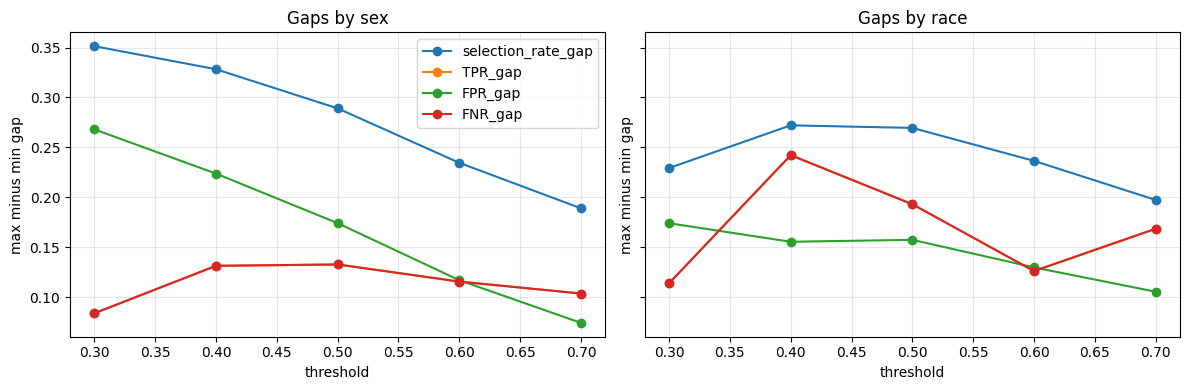

In [8]:
# Visualize how threshold changes affect group gaps

fig, chart_axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

chart_position = 0
for group_column in ["sex", "race"]:
    selected_thresholds = threshold_sweep[threshold_sweep["group_column"] == group_column]
    chart_axis = chart_axes[chart_position]

    for metric_name in ["selection_rate_gap", "TPR_gap", "FPR_gap", "FNR_gap"]:
        chart_axis.plot(selected_thresholds["threshold"], selected_thresholds[metric_name], marker="o", label=metric_name)

    chart_axis.set_title("Gaps by " + group_column)
    chart_axis.set_xlabel("threshold")
    chart_axis.set_ylabel("max minus min gap")
    chart_axis.grid(True, alpha=0.3)
    chart_position = chart_position + 1

chart_axes[0].legend(loc="best")
plt.tight_layout()
plt.show()


## References

- Adult Census Income dataset on HuggingFace: https://huggingface.co/datasets/scikit-learn/adult-census-income
- Becker, B., & Kohavi, R. (1996). Adult [Dataset]. UCI Machine Learning Repository. https://doi.org/10.24432/C5XW20
- Hardt, M., Price, E., & Srebro, N. (2016). Equality of Opportunity in Supervised Learning. Advances in Neural Information Processing Systems, 29. https://papers.nips.cc/paper/6374-equality-of-opportunity-in-supervised-learning

## Summary

You loaded a real dataset, trained two models, computed group fairness metrics, and checked threshold sensitivity. The careful conclusion is that removing protected columns does not automatically remove all group differences.
